## load package


In [58]:

import intake
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import easygems.healpix as egh
import xarray as xr
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from typing import Tuple, List, Optional, Union, Dict
import scipy.signal as signal
from global_land_mask import globe
from metpy.units import units
from metpy.calc import relative_humidity_from_specific_humidity
import time,os,glob,sys,importlib,cmaps,pickle,math,logging
from scipy import fft
import matplotlib.colors as mcolors 

print("="*70)
print("✅ 模块重新加载完成")
print("="*70)

# ============================================================
# 数据和图形保存路径配置（热带区域专用）
# ============================================================
DATA_DIR = "./processed_data/tropical_analysis"
os.makedirs(DATA_DIR, exist_ok=True)

fig_save_dir = "./figures/Cal_qs_qa_tropical/"
os.makedirs(fig_save_dir, exist_ok=True)

# 结果保存路径（用于保存NetCDF文件）
RESULTS_DIR = "./processed_data/tropical_qs_qa_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("="*70)
print(f"📁 数据保存目录: {DATA_DIR}")
print(f"📁 图形保存目录: {fig_save_dir}")
print(f"📁 结果保存目录: {RESULTS_DIR}")
print("="*70)

def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """创建改进的红-白-蓝配色"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()


✅ 模块重新加载完成
📁 数据保存目录: ./processed_data/tropical_analysis
📁 图形保存目录: ./figures/Cal_qs_qa_tropical/
📁 结果保存目录: ./processed_data/tropical_qs_qa_results


In [59]:
def _ocean(ds):
    """Select ocean region"""
    fraction = xr.open_dataset(r'/work/mh1498/m301257/processed_data/ocean_mask_2deg.nc')['__xarray_dataarray_variable__']
    return fraction == 1

def _land(ds):
    """Select land region"""
    return ~_ocean(ds)

def _tropical_region(ds, lat_min=-30, lat_max=30, region_type='all'):
    """
    Select tropical region (options: global, ocean, land)
    
    Parameters:
    -----------
    ds : xarray.DataArray or Dataset
        Input data
    lat_min : float
        Minimum latitude (default -30°)
    lat_max : float
        Maximum latitude (default 30°)
    region_type : str
        Region type, options: 'all'(global), 'ocean', 'land'
    
    Returns:
    --------
    mask : xarray.DataArray
        True for regions meeting criteria, False for others
    """
    # Get latitude coordinate
    if 'lat' in ds.coords:
        lat = ds.lat
    elif 'latitude' in ds.coords:
        lat = ds.latitude
    else:
        raise ValueError("Cannot find latitude coordinate 'lat' or 'latitude'")
    
    # Create tropical mask (lat_min <= lat <= lat_max)
    tropical_mask = (lat >= lat_min) & (lat <= lat_max)
    
    # Select mask based on region type
    if region_type == 'ocean':
        return tropical_mask & _ocean(ds)
    elif region_type == 'land':
        return tropical_mask & _land(ds)
    elif region_type == 'all':
        return tropical_mask
    else:
        raise ValueError(f"Unknown region type: {region_type}. Options: 'all', 'ocean', 'land'")

# Set tropical region range
TROPICAL_LAT_MIN = -30  # 30°S
TROPICAL_LAT_MAX = 30   # 30°N

print("="*70)
print(f"✅ Tropical region defined: {TROPICAL_LAT_MIN}°S - {TROPICAL_LAT_MAX}°N")
print("   Available region types:")
print("   - 'all':   Global (land + ocean)")
print("   - 'ocean': Ocean only")
print("   - 'land':  Land only")
print("="*70)


✅ Tropical region defined: -30°S - 30°N
   Available region types:
   - 'all':   Global (land + ocean)
   - 'ocean': Ocean only
   - 'land':  Land only


# Calculate and Compare qs (Saturation Specific Humidity) and qa (Air Specific Humidity)

Below we analyze the differences in qs and qa across three experiments to see if humidity gradient (qs - qa) is the dominant factor controlling latent heat flux.

Latent Heat Flux Formula: LHF = ρ * Lv * Ce * U * (qs - qa)

Where:
- qs = q_sat(SST, ps): Saturation specific humidity at surface
- qa: Near-surface air specific humidity (2m or lowest layer)

In [60]:
# 加载表面比湿数据 (hus - specific humidity at surface/2m level)
# 从你的 hus_*_layers 文件夹中加载最底层的数据

hus_data_dir = '/work/mh1498/m301257/'

# 加载最底层的 specific humidity (应该是 lev_090 或者查看哪个是最底层)
# 先列出 hus_cntl_layers 目录看看有哪些文件
print("Checking hus data files...")
hus_cntl_dir = f'{hus_data_dir}/data_origin/hus_cntl_layers/'
hus_4co2_dir = f'{hus_data_dir}/data_origin/hus_4co2_layers/'
hus_p4k_dir = f'{hus_data_dir}/data_origin/hus_p4k_layers/'

tas_2m_4co2_file = r'/work/mh1498/m301257/processed_data/2d_layers/tas_4co2/tas_2deg_interp.nc'
tas_2m_cntl_file = r'/work/mh1498/m301257/processed_data/2d_layers/tas_cntl/tas_2deg_interp.nc'
tas_2m_p4k_file = r'/work/mh1498/m301257/processed_data/2d_layers/tas_p4k/tas_2deg_interp.nc'

pressure_cntl_file = r'/work/mh1498/m301257/processed_data/2d_layers/ps_cntl/ps_2deg_interp.nc'
pressure_p4k_file = r'/work/mh1498/m301257/processed_data/2d_layers/ps_p4k/ps_2deg_interp.nc'
pressure_4co2_file = r'/work/mh1498/m301257/processed_data/2d_layers/ps_4co2/ps_2deg_interp.nc'

hus2m_cntl_file = r'/work/mh1498/m301257/processed_data/2d_layers/hus2m_cntl/hus2m_2deg_interp.nc'
hus2m_p4k_file = r'/work/mh1498/m301257/processed_data/2d_layers/hus2m_p4k/hus2m_2deg_interp.nc'
hus2m_4co2_file = r'/work/mh1498/m301257/processed_data/2d_layers/hus2m_4co2/hus2m_2deg_interp.nc'

# 列出文件
if os.path.exists(hus_cntl_dir):
    hus_files = sorted([f for f in os.listdir(hus_cntl_dir) if f.endswith('.nc')])
    print(f"Available hus files: {hus_files}")
    
    # 通常最底层是最后一个或者 lev_090
    # 检查是否有 all_levels 文件
    if 'hus_all_levels.nc' in hus_files:
        print("\nFound hus_all_levels.nc - will load and select the lowest level")
    else:
        print(f"\nWill use the highest level number (likely surface): {hus_files[-1]}")

Checking hus data files...
Available hus files: ['hus_all_levels.nc', 'hus_lev_031.nc', 'hus_lev_035.nc', 'hus_lev_038.nc', 'hus_lev_041.nc', 'hus_lev_046.nc', 'hus_lev_051.nc', 'hus_lev_055.nc', 'hus_lev_058.nc', 'hus_lev_063.nc', 'hus_lev_067.nc', 'hus_lev_071.nc', 'hus_lev_074.nc', 'hus_lev_076.nc', 'hus_lev_078.nc', 'hus_lev_080.nc', 'hus_lev_081.nc', 'hus_lev_083.nc', 'hus_lev_084.nc', 'hus_lev_085.nc', 'hus_lev_087.nc', 'hus_lev_089.nc', 'hus_lev_090.nc']

Found hus_all_levels.nc - will load and select the lowest level


In [61]:

hus_cntl_path = f'{hus_cntl_dir}hus_lev_090.nc'
hus_4co2_path = f'{hus_4co2_dir}hus_lev_090.nc'
hus_p4k_path = f'{hus_p4k_dir}hus_lev_090.nc'

print("Loading specific humidity data...")
hus_cntl = xr.open_dataset(hus_cntl_path)
hus_4co2 = xr.open_dataset(hus_4co2_path)
hus_p4k = xr.open_dataset(hus_p4k_path)
print("\nControl experiment hus:")
print(hus_cntl)
tas2m_cntl = xr.open_dataset(tas_2m_cntl_file)
tas2m_4co2 = xr.open_dataset(tas_2m_4co2_file)
tas2m_p4k = xr.open_dataset(tas_2m_p4k_file)
tas2m_cntl_ocean = tas2m_cntl.where( (tas2m_cntl.tas),)
tas2m_p4k_ocean = tas2m_p4k.where( (tas2m_p4k.tas),)
tas2m_4co2_ocean = tas2m_4co2.where( (tas2m_4co2.tas),)
print("\nControl experiment tas 2m:")
print(tas2m_cntl_ocean)
del tas2m_cntl, tas2m_4co2, tas2m_p4k  # 释放内存
pre_cntl = xr.open_dataset(pressure_cntl_file)
pre_4co2 = xr.open_dataset(pressure_4co2_file)
pre_p4k = xr.open_dataset(pressure_p4k_file)    
print( "\nControl experiment pressure:")
print(pre_cntl)

hus2m_cntl = xr.open_dataset(hus2m_cntl_file)
hus2m_p4k = xr.open_dataset(hus2m_p4k_file)
hus2m_4co2 = xr.open_dataset(hus2m_4co2_file)
hus2m_cntl_ocean = hus2m_cntl.where( (hus2m_cntl.hus2m),)
hus2m_p4k_ocean = hus2m_p4k.where( (hus2m_p4k.hus2m),)
hus2m_4co2_ocean = hus2m_4co2.where( (hus2m_4co2.hus2m),)
print("\nControl experiment hus 2m:")
print(hus2m_cntl_ocean)
del hus2m_cntl, hus2m_p4k, hus2m_4co2  # 释放内存

Loading specific humidity data...

Control experiment hus:
<xarray.Dataset> Size: 111MB
Dimensions:  (level: 1, time: 5114, lat: 15, lon: 180)
Coordinates:
  * level    (level) int64 8B 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    hus      (level, time, lat, lon) float64 110MB ...

Control experiment tas 2m:
<xarray.Dataset> Size: 111MB
Dimensions:  (time: 5114, lat: 15, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    tas      (time, lat, lon) float64 110MB 293.1 292.7 292.5 ... 295.8 295.1

Control experiment pressure:
<xarray.Dataset> Size: 111MB
Dime

In [62]:

def esat(t, p):
    """
    usage: es = qsat(t,p)
    Returns saturation vapor pressure es (mb) given t(K) and p(mb).

    After Buck, 1981: J.Appl.Meteor., 20, 1527-1532

    Returns ndarray float for any numeric object input.
    """
    t2 = t-273.15
    return 6.1121 * np.exp(17.502 * t2 / (240.97 + t2)) * (1.0007 + p * 3.46e-6)

def q_sat(t, p):
    

    # compute saturation specific humidity
    # p is pressure in mb (hPa) -> at the surface, p is surface pressure
    # t is SST in deg K

    # compute saturation pressure
    es = esat(t, p)
    epsilon = 0.622
    return epsilon * es / p

def q_from_rh(t,p,rh, epsilon=0.622):

  # compute air specific humidity -> you should already have this variable as ICON output!

    '''
    usage:
    t in K
    p in hPa or mb
    rh : relative humidity in fraction between 0 and 1
    returns: q in kg/kg
    '''

    e_star = esat(t,p)
    e = rh*e_star
    return epsilon*e/p

def saturation_water_vapor_pressure(t2m):
    """
    Calculate saturation water vapor pressure over liquid water using the
    Tetens formula.

    Parameters:
    t : float or ndarray
        Temperature in Kelvin.

    Returns:
    es : float or ndarray
        Saturation water vapor pressure in hPa.
    """

    e0 = 6.112
    Lv = 2.5e6  # J/kg
    Rv = 461.5  # J/(kg·K)
    es = e0 * np.exp(Lv/Rv * (1/273.15 - 1/t2m))
    return es
  
  
def compute_saturation_specific_humidity(t2m, p):
    """
    Calculate saturation specific humidity.

    Parameters:
    t2m : float or ndarray
        Temperature in Kelvin.
    p : float or ndarray
        Pressure in hPa.

    Returns:
    qsat : float or ndarray
        Saturation specific humidity in kg/kg.
    """
    epsilon = 0.622
    es = saturation_water_vapor_pressure(t2m)
    qsat = epsilon * es / p
    return qsat

In [63]:
saturation_specific_humidity_cntl = q_sat(tas2m_cntl_ocean['tas'],pre_cntl['ps']/100,)
saturation_specific_humidity_p4k  = q_sat(tas2m_p4k_ocean['tas'],pre_p4k['ps']/100,)
saturation_specific_humidity_4co2 = q_sat(tas2m_4co2_ocean['tas'],pre_4co2['ps']/100,)


In [64]:
air_specific_humidity_cntl = hus2m_cntl_ocean['hus2m']
air_specific_humidity_4co2 = hus2m_4co2_ocean['hus2m']
air_specific_humidity_p4k = hus2m_p4k_ocean['hus2m']

In [65]:

print("Calculating humidity gradient (dq = qs - qa)...")

# Control experiment
dq_cntl = saturation_specific_humidity_cntl - air_specific_humidity_cntl

# 4CO2 experiment
dq_4co2 = saturation_specific_humidity_4co2 - air_specific_humidity_4co2

# P4K experiment
dq_p4k = saturation_specific_humidity_p4k - air_specific_humidity_p4k

print("\nHumidity gradient calculated!")
print(f"Control dq range: {float(dq_cntl.min()):.6f} to {float(dq_cntl.max()):.6f} kg/kg")
print(f"4CO2 dq range: {float(dq_4co2.min()):.6f} to {float(dq_4co2.max()):.6f} kg/kg")
print(f"P4K dq range: {float(dq_p4k.min()):.6f} to {float(dq_p4k.max()):.6f} kg/kg")


ds_differece_qs_qa = xr.Dataset({
    'diff_qs-qa_cntl': dq_cntl,
    'diff_qs-qa_4co2': dq_4co2,
    'diff_qs-qa_p4k': dq_p4k
})

# ds_differece_qs_qa.to_netcdf(os.path.join('/work/mh1498/m301257/3D_data', 'difference_qs_qa.nc'))

Calculating humidity gradient (dq = qs - qa)...

Humidity gradient calculated!
Control dq range: -0.000089 to 0.037125 kg/kg
4CO2 dq range: -0.000075 to 0.041655 kg/kg
P4K dq range: -0.000139 to 0.054698 kg/kg


In [66]:
# ============================================================================
# Calculate tropical regional mean values (separate: global, ocean, land)
# ============================================================================

print("="*80)
print("Calculating tropical regional mean values (30°S-30°N)")
print("="*80)

# Define region types
REGIONS = {
    'all': 'Global (Land + Ocean)',
    'ocean': 'Ocean',
    'land': 'Land'
}

# Create dictionary to store regional means
regional_means = {}

for region_key, region_name in REGIONS.items():
    print(f"\n{'='*70}")
    print(f"🌍 Processing region: {region_name}")
    print(f"{'='*70}")
    
    # Apply regional mask
    qs_cntl_region = saturation_specific_humidity_cntl.where(
        _tropical_region(saturation_specific_humidity_cntl, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    qs_4co2_region = saturation_specific_humidity_4co2.where(
        _tropical_region(saturation_specific_humidity_4co2, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    qs_p4k_region = saturation_specific_humidity_p4k.where(
        _tropical_region(saturation_specific_humidity_p4k, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    
    qa_cntl_region = air_specific_humidity_cntl.where(
        _tropical_region(air_specific_humidity_cntl, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    qa_4co2_region = air_specific_humidity_4co2.where(
        _tropical_region(air_specific_humidity_4co2, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    qa_p4k_region = air_specific_humidity_p4k.where(
        _tropical_region(air_specific_humidity_p4k, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    
    dq_cntl_region = dq_cntl.where(
        _tropical_region(dq_cntl, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    dq_4co2_region = dq_4co2.where(
        _tropical_region(dq_4co2, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    dq_p4k_region = dq_p4k.where(
        _tropical_region(dq_p4k, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    
    # Calculate means
    regional_means[region_key] = {
        'qs_cntl': float(qs_cntl_region.mean(skipna=True)),
        'qs_4co2': float(qs_4co2_region.mean(skipna=True)),
        'qs_p4k': float(qs_p4k_region.mean(skipna=True)),
        'qa_cntl': float(qa_cntl_region.mean(skipna=True)),
        'qa_4co2': float(qa_4co2_region.mean(skipna=True)),
        'qa_p4k': float(qa_p4k_region.mean(skipna=True)),
        'dq_cntl': float(dq_cntl_region.mean(skipna=True)),
        'dq_4co2': float(dq_4co2_region.mean(skipna=True)),
        'dq_p4k': float(dq_p4k_region.mean(skipna=True)),
        # Store regional data for plotting
        'qs_cntl_field': qs_cntl_region.mean(dim='time', skipna=True),
        'qs_4co2_field': qs_4co2_region.mean(dim='time', skipna=True),
        'qs_p4k_field': qs_p4k_region.mean(dim='time', skipna=True),
        'qa_cntl_field': qa_cntl_region.mean(dim='time', skipna=True),
        'qa_4co2_field': qa_4co2_region.mean(dim='time', skipna=True),
        'qa_p4k_field': qa_p4k_region.mean(dim='time', skipna=True),
        'dq_cntl_field': dq_cntl_region.mean(dim='time', skipna=True),
        'dq_4co2_field': dq_4co2_region.mean(dim='time', skipna=True),
        'dq_p4k_field': dq_p4k_region.mean(dim='time', skipna=True),
    }
    
    # Print statistics for this region
    print(f"\n{region_name} - Control:")
    print(f"  qs = {regional_means[region_key]['qs_cntl']:.6f} kg/kg")
    print(f"  qa = {regional_means[region_key]['qa_cntl']:.6f} kg/kg")
    print(f"  dq = {regional_means[region_key]['dq_cntl']:.6f} kg/kg")
    
    print(f"\n{region_name} - 4CO2:")
    print(f"  qs = {regional_means[region_key]['qs_4co2']:.6f} kg/kg")
    print(f"  qa = {regional_means[region_key]['qa_4co2']:.6f} kg/kg")
    print(f"  dq = {regional_means[region_key]['dq_4co2']:.6f} kg/kg")
    
    print(f"\n{region_name} - P4K:")
    print(f"  qs = {regional_means[region_key]['qs_p4k']:.6f} kg/kg")
    print(f"  qa = {regional_means[region_key]['qa_p4k']:.6f} kg/kg")
    print(f"  dq = {regional_means[region_key]['dq_p4k']:.6f} kg/kg")

print("\n" + "="*80)
print("✅ All regional calculations completed!")
print("="*80)

# Save regional mean data to NetCDF
print("\n💾 Saving regional mean data...")
regional_means_ds = xr.Dataset({
    f'{var}_{region}': (['scalar'], [regional_means[region][var]])
    for region in REGIONS.keys()
    for var in ['qs_cntl', 'qs_4co2', 'qs_p4k', 'qa_cntl', 'qa_4co2', 'qa_p4k', 'dq_cntl', 'dq_4co2', 'dq_p4k']
})

regional_means_file = os.path.join(RESULTS_DIR, 'tropical_regional_means.nc')
regional_means_ds.to_netcdf(regional_means_file)
print(f"✅ Regional mean data saved: {regional_means_file}")


Calculating tropical regional mean values (30°S-30°N)

🌍 Processing region: Global (Land + Ocean)

Global (Land + Ocean) - Control:
  qs = 0.019797 kg/kg
  qa = 0.014510 kg/kg
  dq = 0.005286 kg/kg

Global (Land + Ocean) - 4CO2:
  qs = 0.020104 kg/kg
  qa = 0.014887 kg/kg
  dq = 0.005217 kg/kg

Global (Land + Ocean) - P4K:
  qs = 0.025591 kg/kg
  qa = 0.018887 kg/kg
  dq = 0.006703 kg/kg

🌍 Processing region: Ocean

Global (Land + Ocean) - Control:
  qs = 0.019797 kg/kg
  qa = 0.014510 kg/kg
  dq = 0.005286 kg/kg

Global (Land + Ocean) - 4CO2:
  qs = 0.020104 kg/kg
  qa = 0.014887 kg/kg
  dq = 0.005217 kg/kg

Global (Land + Ocean) - P4K:
  qs = 0.025591 kg/kg
  qa = 0.018887 kg/kg
  dq = 0.006703 kg/kg

🌍 Processing region: Ocean

Ocean - Control:
  qs = 0.020103 kg/kg
  qa = 0.015219 kg/kg
  dq = 0.004884 kg/kg

Ocean - 4CO2:
  qs = 0.020350 kg/kg
  qa = 0.015552 kg/kg
  dq = 0.004798 kg/kg

Ocean - P4K:
  qs = 0.025670 kg/kg
  qa = 0.019782 kg/kg
  dq = 0.005887 kg/kg

🌍 Processing r

## Regional Comparison Analysis (Global vs Ocean vs Land)


✅ Regional comparison figure saved: ./figures/Cal_qs_qa_tropical//regional_comparison_all_vars.png


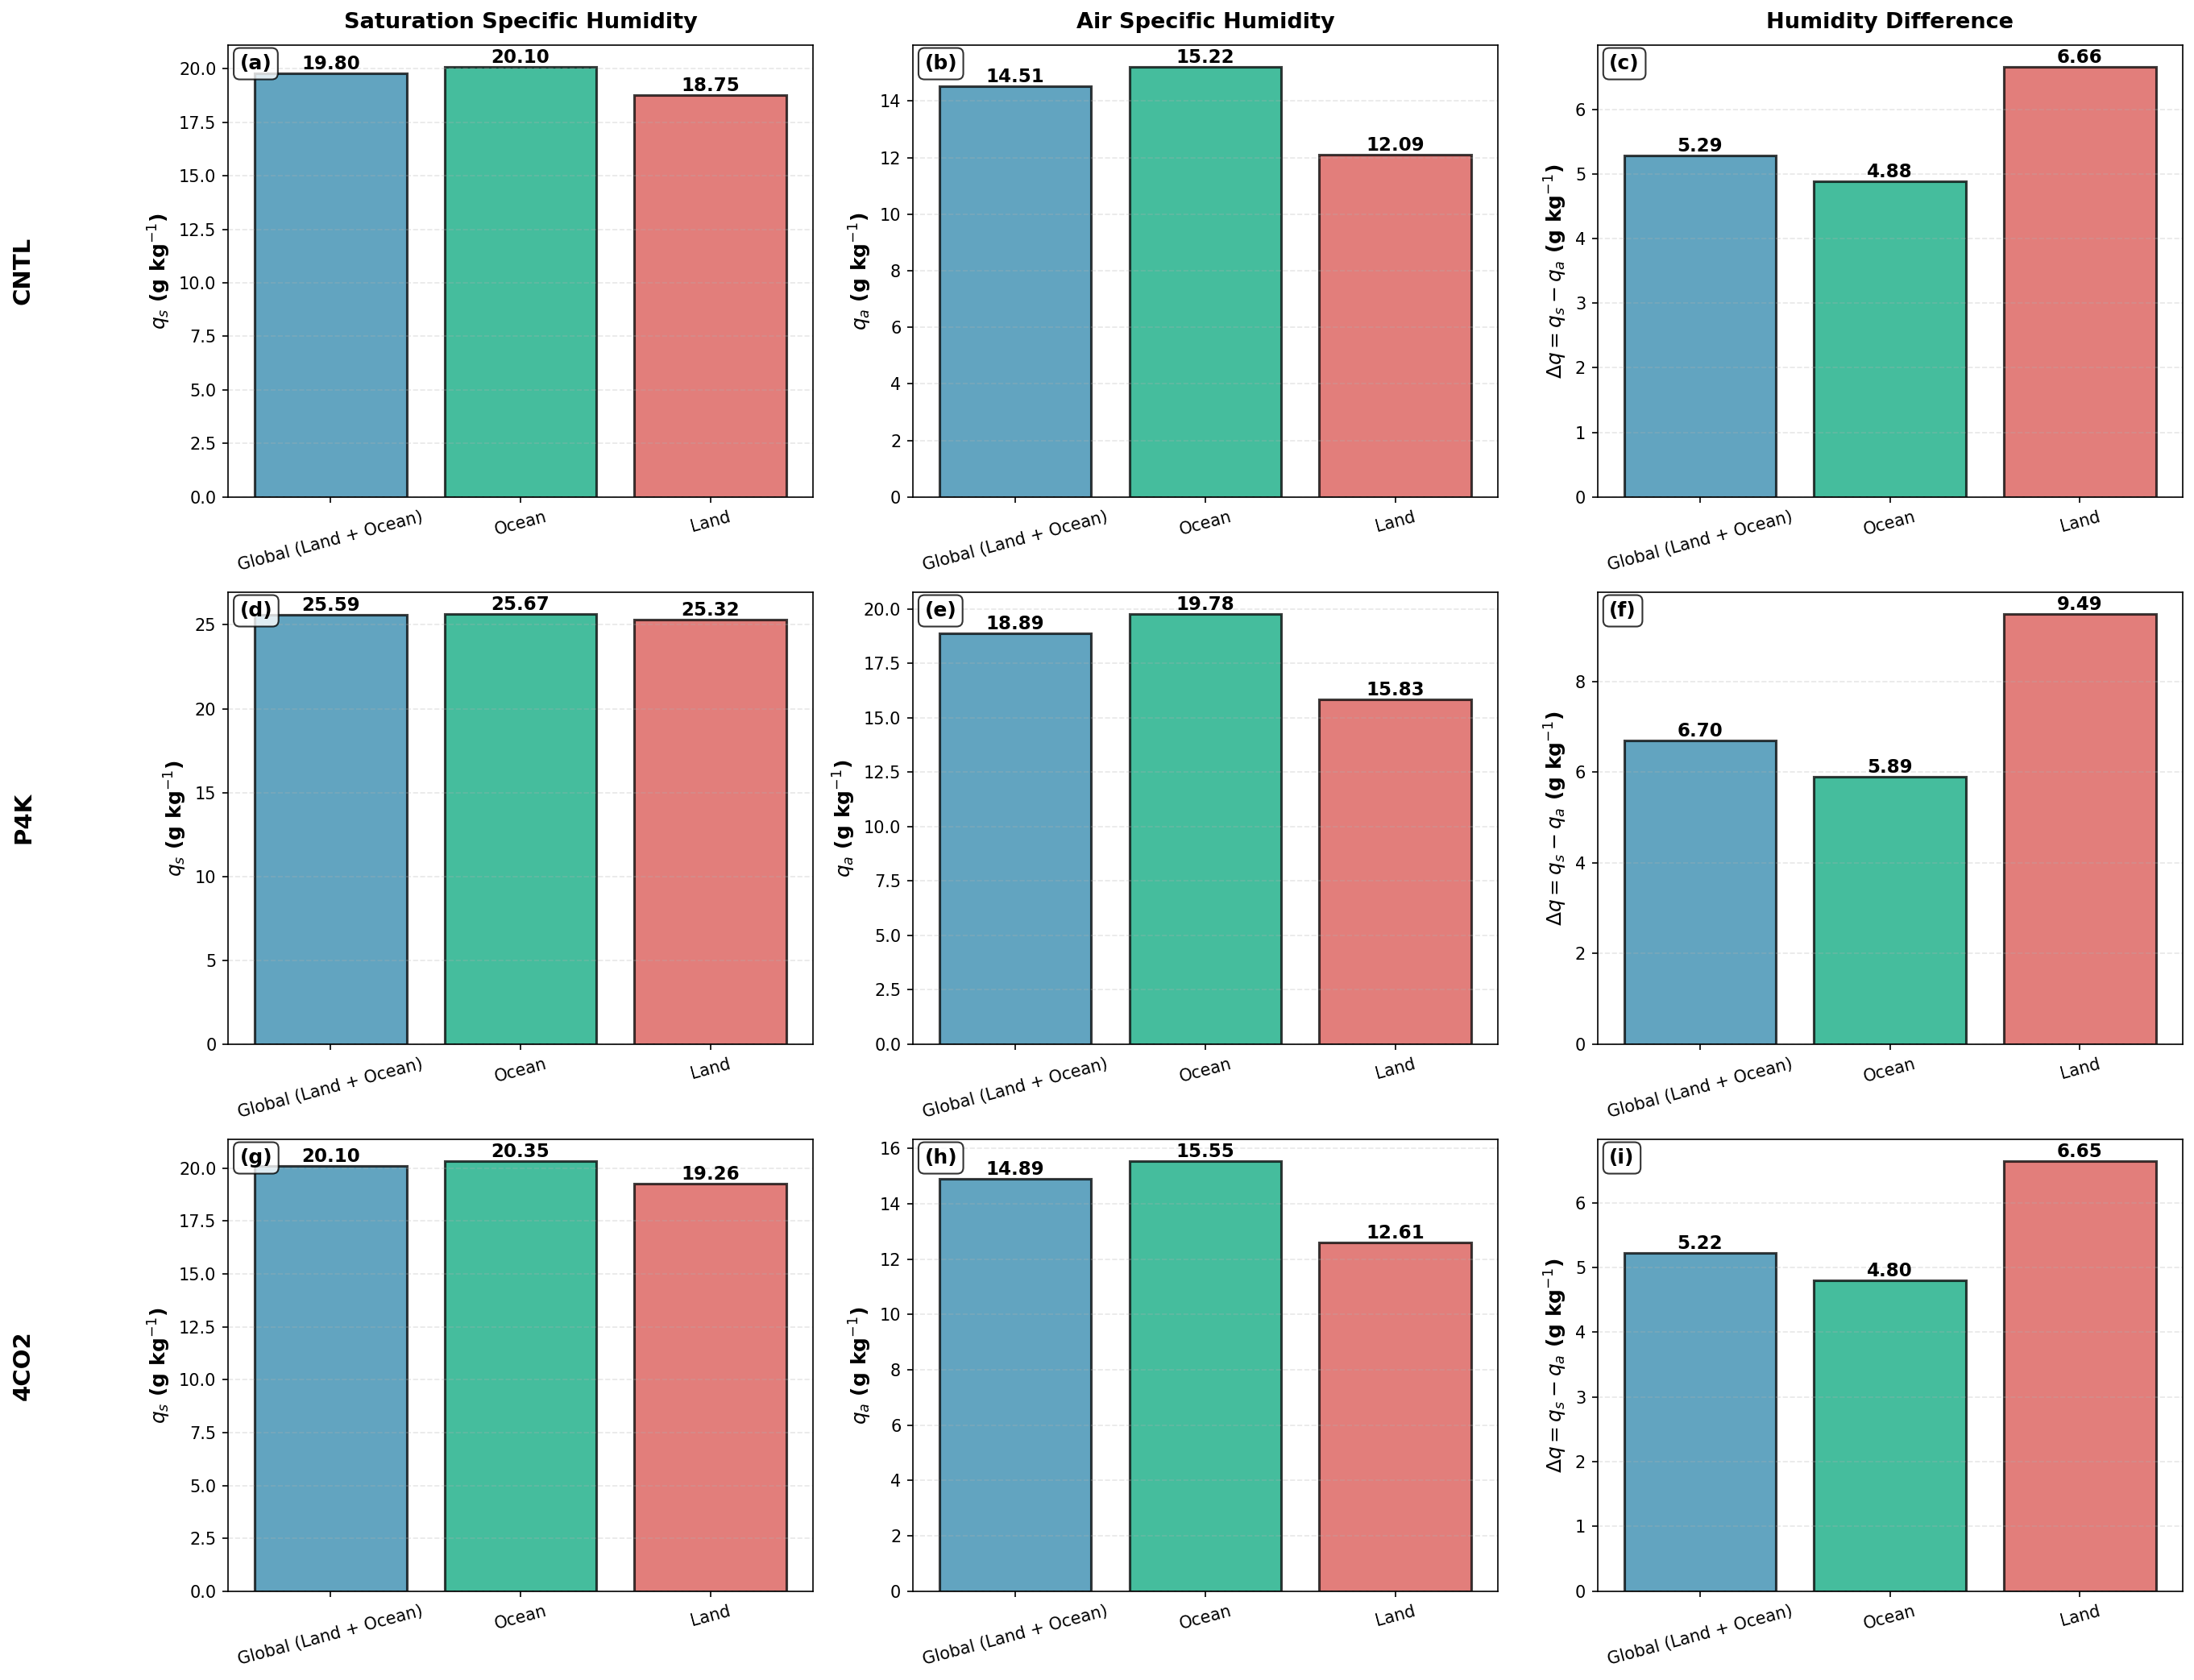

In [67]:
# ============================================================================
# Plot regional comparison bar charts: Global, Ocean, Land for qs, qa, dq
# ============================================================================

fig_regional, axes = plt.subplots(3, 3, figsize=(18, 14), dpi=150)

# Define colors
colors_regional = {
    'all': '#2E86AB',    # Blue - Global
    'ocean': '#06A77D',  # Green - Ocean
    'land': '#D9534F'    # Red - Land
}

experiments = ['CNTL', 'P4K', '4CO2']
variables = ['qs', 'qa', 'dq']
var_labels = {
    'qs': r'$q_s$ (g kg$^{-1}$)',
    'qa': r'$q_a$ (g kg$^{-1}$)',
    'dq': r'$\Delta q = q_s - q_a$ (g kg$^{-1}$)'
}
var_titles = {
    'qs': 'Saturation Specific Humidity',
    'qa': 'Air Specific Humidity',
    'dq': 'Humidity Difference'
}

# Plot comparison for each variable and experiment
for i, exp in enumerate(experiments):
    for j, var in enumerate(variables):
        ax = axes[i, j]
        
        # Prepare data
        values = []
        region_labels = []
        colors_bars = []
        
        for region_key, region_name in REGIONS.items():
            var_key = f'{var}_{exp.lower()}'
            value = regional_means[region_key][var_key] * 1000  # Convert to g/kg
            values.append(value)
            region_labels.append(region_name)
            colors_bars.append(colors_regional[region_key])
        
        # Create bar chart
        bars = ax.bar(region_labels, values, color=colors_bars, alpha=0.75, edgecolor='black', linewidth=1.5)
        
        # Add value labels
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.2f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Formatting
        ax.set_ylabel(var_labels[var], fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.tick_params(axis='x', rotation=15, labelsize=10)
        
        # Set title
        if i == 0:
            ax.set_title(f'{var_titles[var]}', fontsize=13, fontweight='bold', pad=10)
        
        # Add experiment label on left side
        if j == 0:
            ax.text(-0.35, 0.5, exp, transform=ax.transAxes,
                   fontsize=14, fontweight='bold', rotation=90,
                   ha='center', va='center')
        
        # Add panel label
        panel_label = chr(97 + i*3 + j)  # a, b, c, ...
        ax.text(0.02, 0.98, f'({panel_label})', transform=ax.transAxes,
               fontsize=12, fontweight='bold', va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{fig_save_dir}/regional_comparison_all_vars.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Regional comparison figure saved: {fig_save_dir}/regional_comparison_all_vars.png")
plt.show()


✅ Regional relative changes figure saved: ./figures/Cal_qs_qa_tropical//regional_relative_changes.png


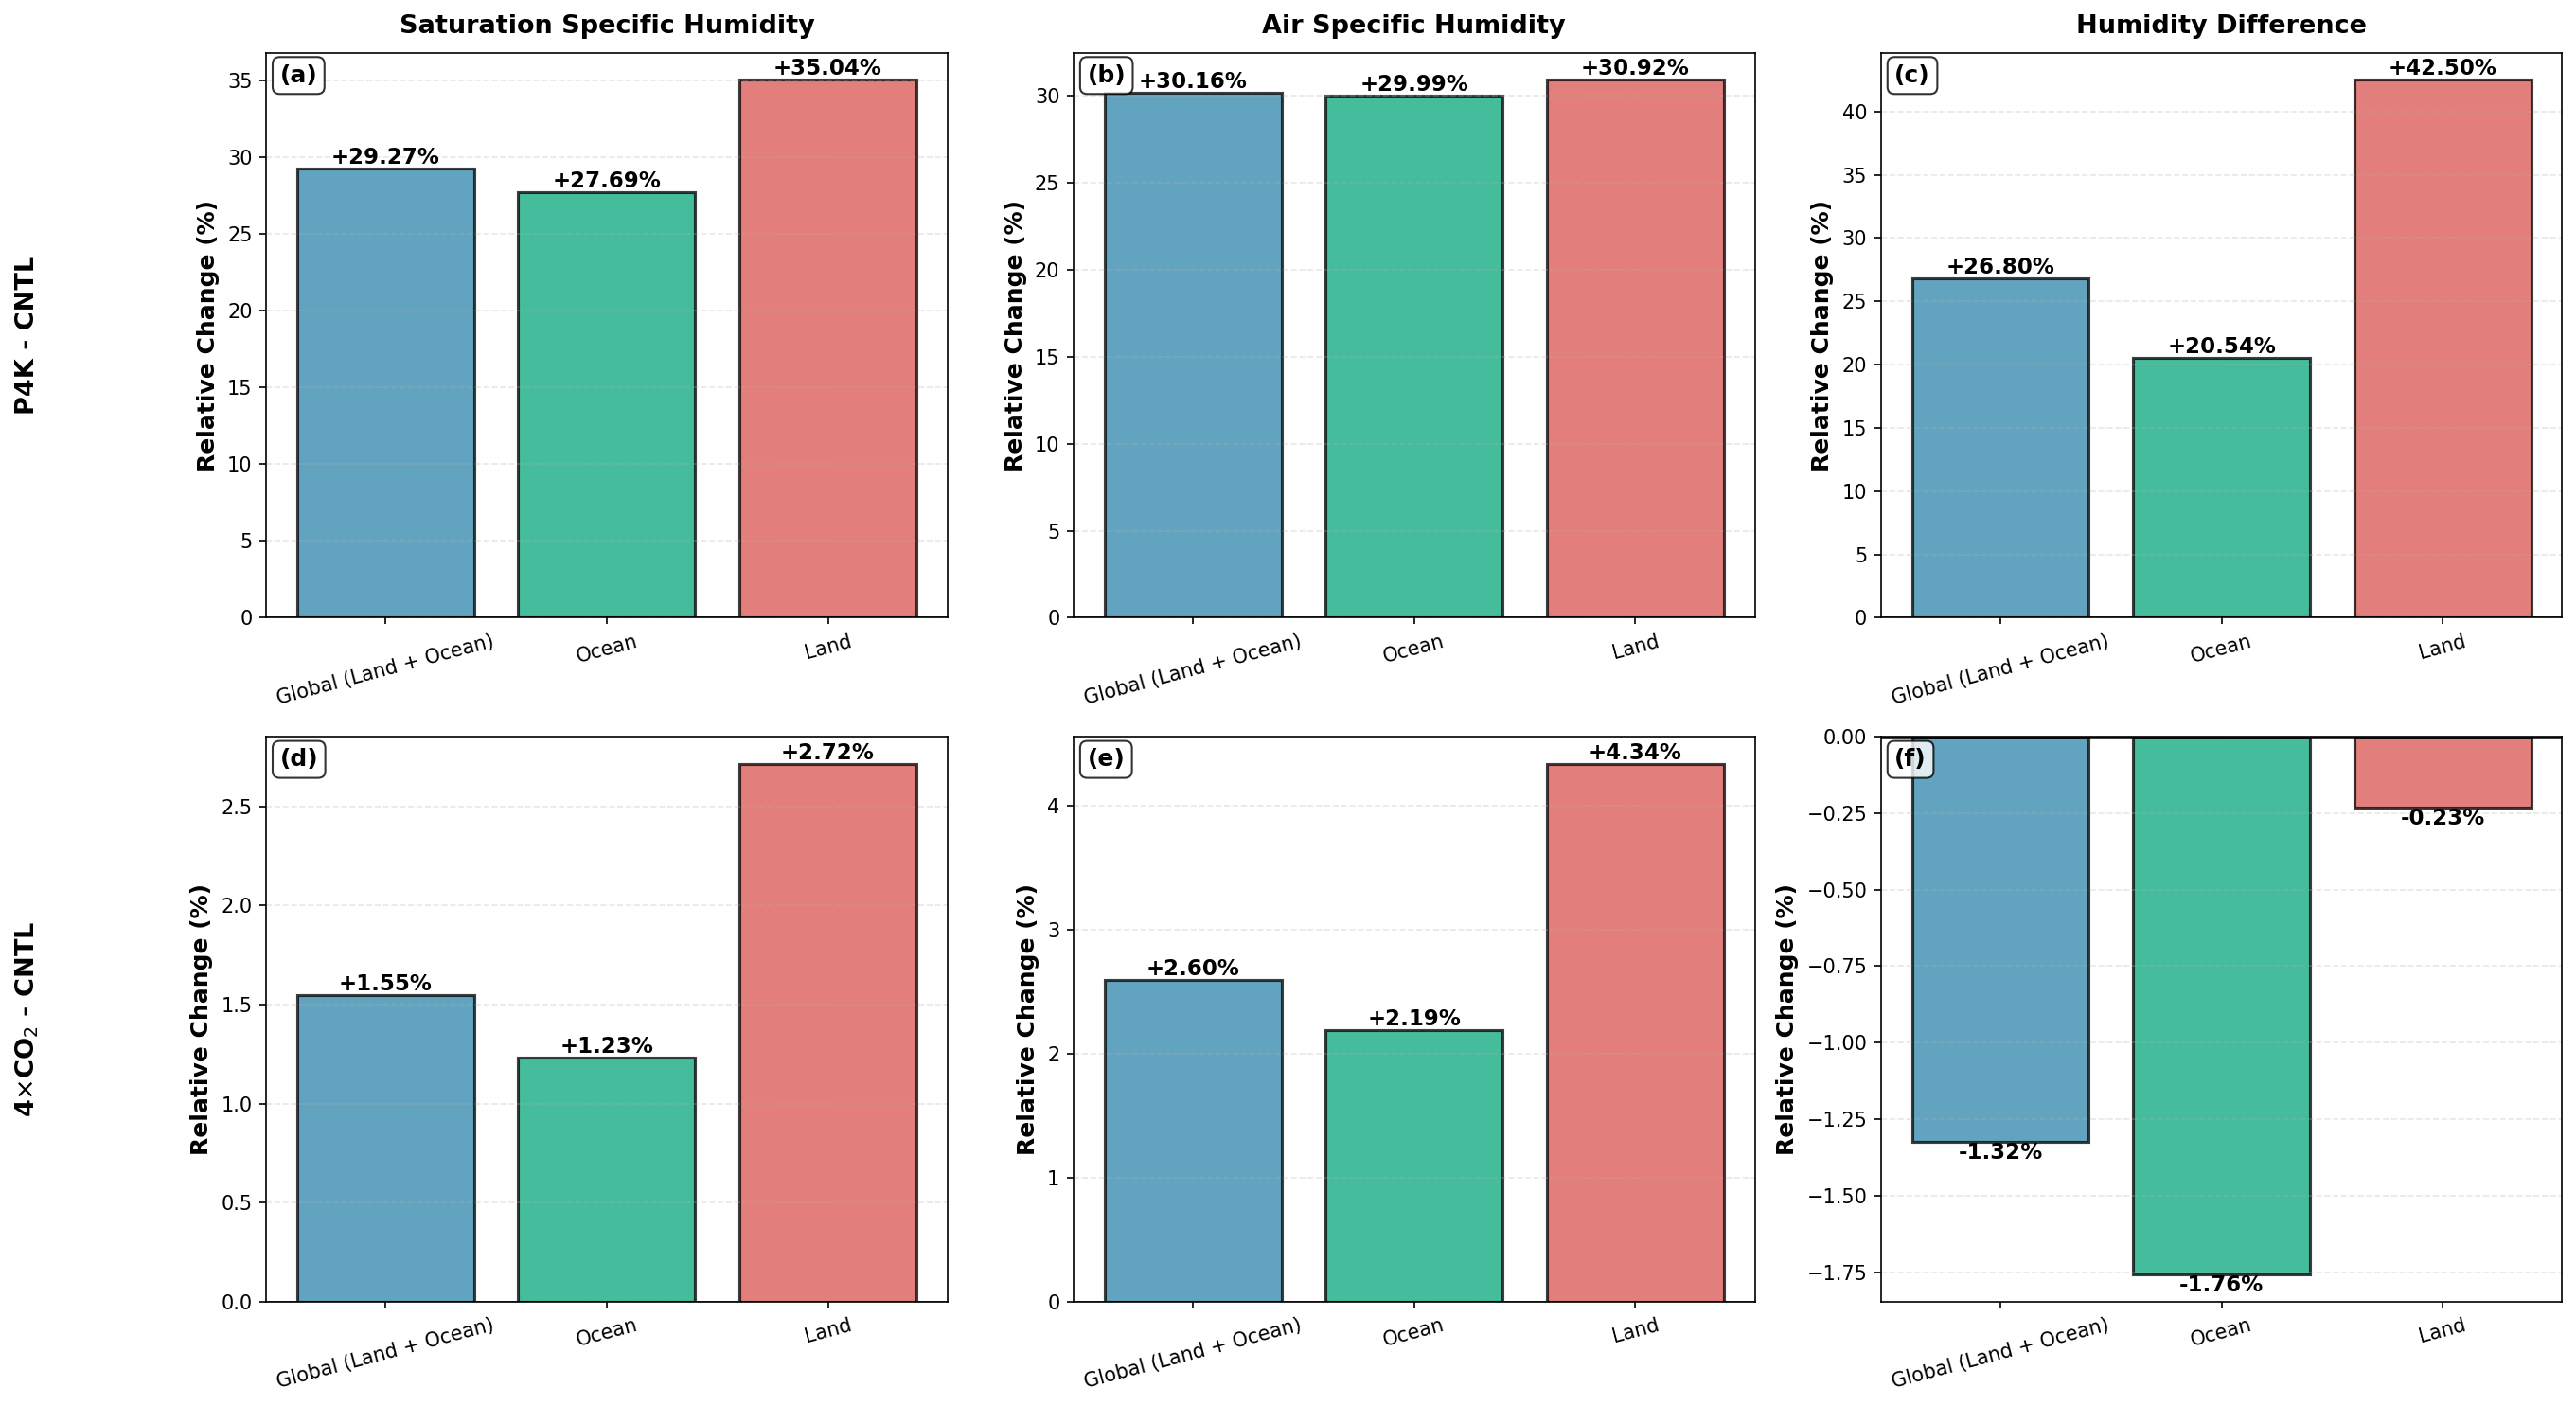

In [68]:
# ============================================================================
# Plot relative change comparison (P4K and 4CO2 relative to CNTL)
# ============================================================================

fig_changes, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)

# P4K and 4CO2 changes
exp_changes = ['P4K', '4CO2']
exp_labels = ['P4K - CNTL', r'4$\times$CO$_2$ - CNTL']

for row, (exp, exp_label) in enumerate(zip(exp_changes, exp_labels)):
    for col, var in enumerate(variables):
        ax = axes[row, col]
        
        # Calculate relative changes
        changes = []
        region_labels = []
        colors_bars = []
        
        for region_key, region_name in REGIONS.items():
            cntl_value = regional_means[region_key][f'{var}_cntl']
            exp_value = regional_means[region_key][f'{var}_{exp.lower()}']
            
            # Relative change percentage
            rel_change = (exp_value - cntl_value) / cntl_value * 100
            changes.append(rel_change)
            region_labels.append(region_name)
            colors_bars.append(colors_regional[region_key])
        
        # Create bar chart
        bars = ax.bar(region_labels, changes, color=colors_bars, alpha=0.75, 
                      edgecolor='black', linewidth=1.5)
        
        # Add zero line
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.2, zorder=1)
        
        # Add value labels
        for bar, change in zip(bars, changes):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{change:+.2f}%',
                   ha='center', va='bottom' if height > 0 else 'top',
                   fontsize=11, fontweight='bold')
        
        # Formatting
        ax.set_ylabel('Relative Change (%)', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.tick_params(axis='x', rotation=15, labelsize=10)
        
        # Set title
        if row == 0:
            ax.set_title(f'{var_titles[var]}', fontsize=13, fontweight='bold', pad=10)
        
        # Add experiment label on left side
        if col == 0:
            ax.text(-0.35, 0.5, exp_label, transform=ax.transAxes,
                   fontsize=13, fontweight='bold', rotation=90,
                   ha='center', va='center')
        
        # Add panel label
        panel_label = chr(97 + row*3 + col)  # a, b, c, ...
        ax.text(0.02, 0.98, f'({panel_label})', transform=ax.transAxes,
               fontsize=12, fontweight='bold', va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{fig_save_dir}/regional_relative_changes.png', dpi=300, bbox_inches='tight')
print(f"✅ Regional relative changes figure saved: {fig_save_dir}/regional_relative_changes.png")
plt.show()


In [69]:
# ============================================================================
# Print detailed statistical table for regional comparison
# ============================================================================

print("\n" + "="*100)
print(" "*30 + "Tropical Regional Statistics Table (30°S-30°N)")
print("="*100)

for var in variables:
    print(f"\n{'='*100}")
    print(f" {var_titles[var]} ({var})")
    print(f"{'='*100}")
    print(f"{'Region':<15} {'CNTL':>15} {'P4K':>15} {'4CO2':>15} {'ΔP4K':>15} {'Δ4CO2':>15}")
    print(f"{'':<15} {'(g/kg)':>15} {'(g/kg)':>15} {'(g/kg)':>15} {'(%)':>15} {'(%)':>15}")
    print("-"*100)
    
    for region_key, region_name in REGIONS.items():
        cntl = regional_means[region_key][f'{var}_cntl'] * 1000
        p4k = regional_means[region_key][f'{var}_p4k'] * 1000
        co2 = regional_means[region_key][f'{var}_4co2'] * 1000
        
        delta_p4k = (p4k - cntl) / cntl * 100
        delta_co2 = (co2 - cntl) / cntl * 100
        
        print(f"{region_name:<15} {cntl:>15.3f} {p4k:>15.3f} {co2:>15.3f} "
              f"{delta_p4k:>14.2f}% {delta_co2:>14.2f}%")

print("\n" + "="*100)
print("✅ Regional statistics table output completed")
print("="*100)



                              Tropical Regional Statistics Table (30°S-30°N)

 Saturation Specific Humidity (qs)
Region                     CNTL             P4K            4CO2            ΔP4K           Δ4CO2
                         (g/kg)          (g/kg)          (g/kg)             (%)             (%)
----------------------------------------------------------------------------------------------------
Global (Land + Ocean)          19.797          25.591          20.104          29.27%           1.55%
Ocean                    20.103          25.670          20.350          27.69%           1.23%
Land                     18.750          25.320          19.260          35.04%           2.72%

 Air Specific Humidity (qa)
Region                     CNTL             P4K            4CO2            ΔP4K           Δ4CO2
                         (g/kg)          (g/kg)          (g/kg)             (%)             (%)
------------------------------------------------------------------------------

## Bar Charts: Climatology Comparison (Ocean Region)


✅ Bar chart saved: ./figures/Cal_qs_qa_tropical//humidity_bar_comparison.png


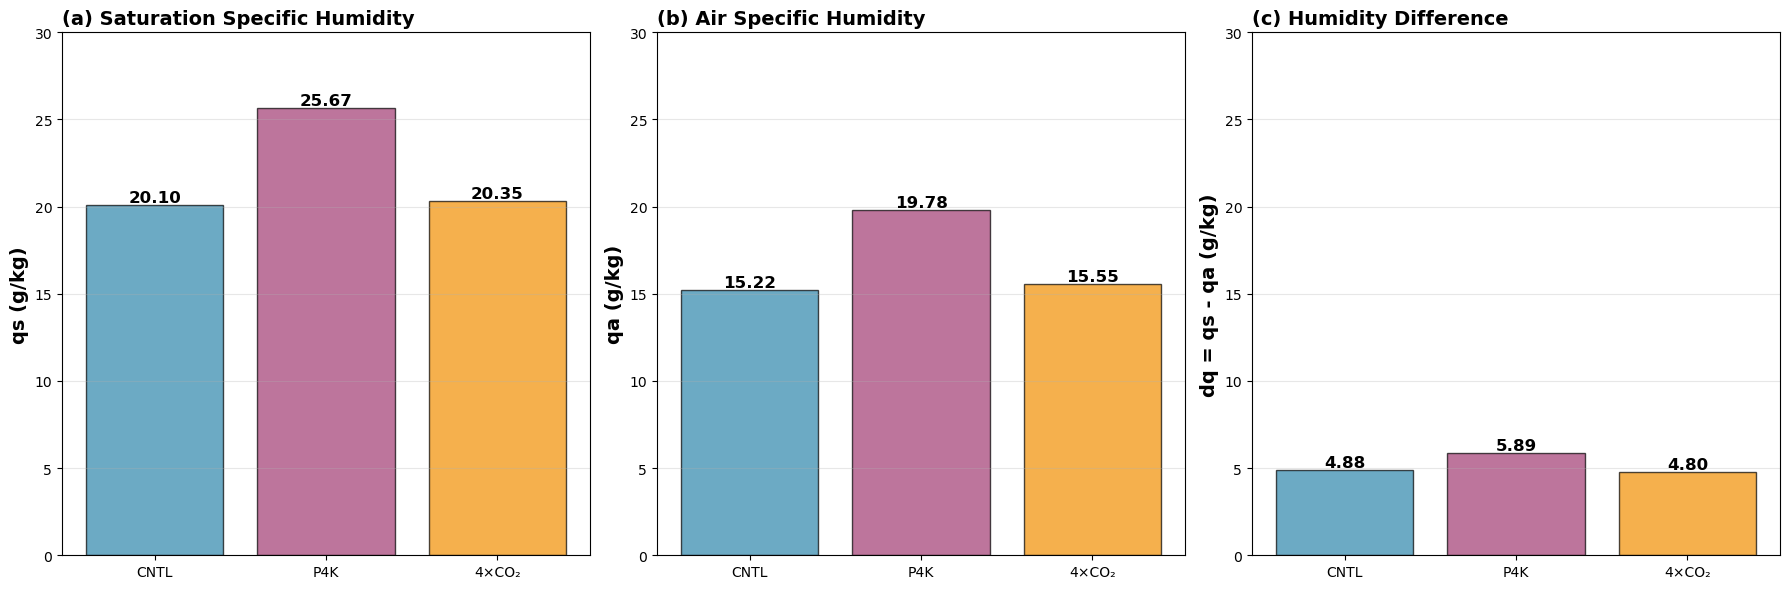

In [70]:
# Create bar charts comparing tropical ocean mean qs, qa, dq
# Using ocean region data from regional_means dictionary

color_cntl = '#2E86AB'
color_p4k = '#A23B72'
color_4co2 = '#F18F01'

fig_bar2, axes_bar2 = plt.subplots(1, 3, figsize=(18, 6))

experiments_list = ['CNTL', 'P4K', '4×CO₂']
colors_list = [color_cntl, color_p4k, color_4co2]

# Prepare data - using ocean region
qs_values = [regional_means['ocean']['qs_cntl']*1000, 
             regional_means['ocean']['qs_p4k']*1000, 
             regional_means['ocean']['qs_4co2']*1000]
qa_values = [regional_means['ocean']['qa_cntl']*1000, 
             regional_means['ocean']['qa_p4k']*1000, 
             regional_means['ocean']['qa_4co2']*1000]
dq_values = [regional_means['ocean']['dq_cntl']*1000, 
             regional_means['ocean']['dq_p4k']*1000, 
             regional_means['ocean']['dq_4co2']*1000]

# Subplot 1: qs
axes_bar2[0].bar(experiments_list, qs_values, color=colors_list, alpha=0.7, edgecolor='black')
axes_bar2[0].set_ylabel('qs (g/kg)', fontsize=14, fontweight='bold')
axes_bar2[0].set_title('(a) Saturation Specific Humidity', fontsize=14, fontweight='bold', loc='left')
axes_bar2[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(qs_values):
    axes_bar2[0].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes_bar2[0].set_ylim(0, 30)

# Subplot 2: qa
axes_bar2[1].bar(experiments_list, qa_values, color=colors_list, alpha=0.7, edgecolor='black')
axes_bar2[1].set_ylabel('qa (g/kg)', fontsize=14, fontweight='bold')
axes_bar2[1].set_title('(b) Air Specific Humidity', fontsize=14, fontweight='bold', loc='left')
axes_bar2[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(qa_values):
    axes_bar2[1].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes_bar2[1].set_ylim(0, 30)

# Subplot 3: dq
axes_bar2[2].bar(experiments_list, dq_values, color=colors_list, alpha=0.7, edgecolor='black')
axes_bar2[2].set_ylabel('dq = qs - qa (g/kg)', fontsize=14, fontweight='bold')
axes_bar2[2].set_title('(c) Humidity Difference', fontsize=14, fontweight='bold', loc='left')
axes_bar2[2].grid(axis='y', alpha=0.3)
axes_bar2[2].set_ylim(0, 30)
for i, v in enumerate(dq_values):
    axes_bar2[2].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{fig_save_dir}/humidity_bar_comparison.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Bar chart saved: {fig_save_dir}/humidity_bar_comparison.png")
plt.show()

### Relative Changes Bar Charts

✅ Changes bar chart saved: ./figures/Cal_qs_qa_tropical//humidity_changes_bar_comparison.png


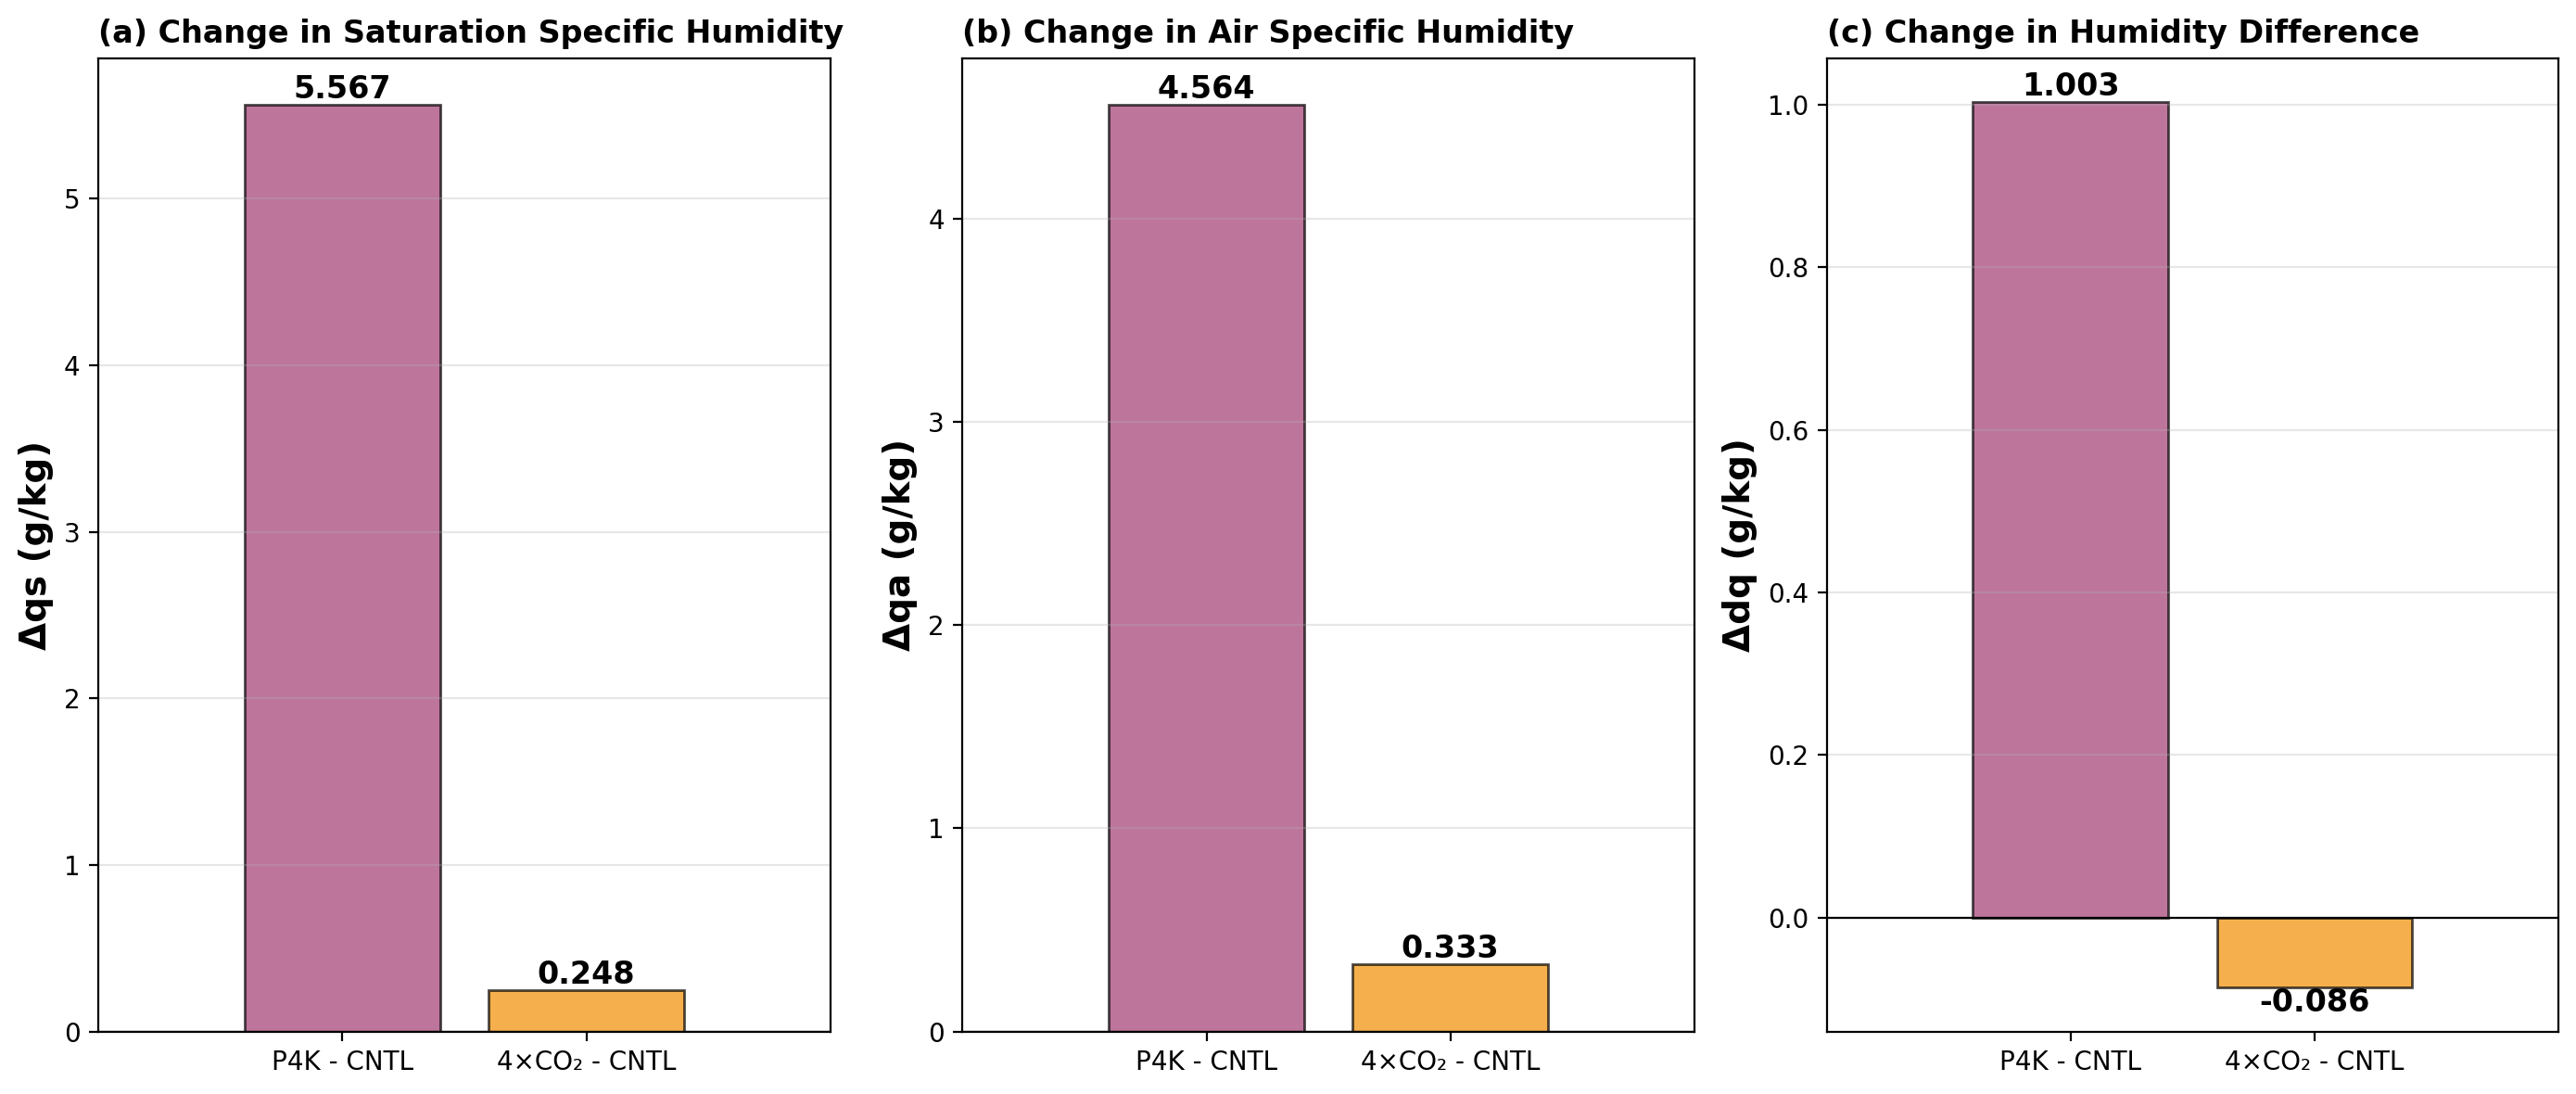

In [71]:
# Create bar chart for changes (Δqs, Δqa, Δdq) - Ocean region

fig_bar3, axes_bar3 = plt.subplots(1, 3, figsize=(14, 6), dpi=200)

experiments_change = [r'P4K - CNTL', r'4×CO₂ - CNTL']
colors_change = [color_p4k, color_4co2]

# Prepare change data (unit: g/kg) - using ocean region
dqs_values = [(regional_means['ocean']['qs_p4k'] - regional_means['ocean']['qs_cntl'])*1000,
              (regional_means['ocean']['qs_4co2'] - regional_means['ocean']['qs_cntl'])*1000]
dqa_values = [(regional_means['ocean']['qa_p4k'] - regional_means['ocean']['qa_cntl'])*1000,
              (regional_means['ocean']['qa_4co2'] - regional_means['ocean']['qa_cntl'])*1000]
ddq_values = [(regional_means['ocean']['dq_p4k'] - regional_means['ocean']['dq_cntl'])*1000,
              (regional_means['ocean']['dq_4co2'] - regional_means['ocean']['dq_cntl'])*1000]

# Subplot 1: Δqs
bars1 = axes_bar3[0].bar(experiments_change, dqs_values, color=colors_change, alpha=0.7, edgecolor='black')
axes_bar3[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes_bar3[0].set_ylabel('Δqs (g/kg)', fontsize=14, fontweight='bold')
axes_bar3[0].set_title('(a) Change in Saturation Specific Humidity', fontsize=12, fontweight='bold', loc='left')
axes_bar3[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(dqs_values):
    axes_bar3[0].text(i, v, f'{v:.3f}', ha='center', va='bottom' if v > 0 else 'top', 
                      fontsize=12, fontweight='bold')

# Subplot 2: Δqa
bars2 = axes_bar3[1].bar(experiments_change, dqa_values, color=colors_change, alpha=0.7, edgecolor='black')
axes_bar3[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes_bar3[1].set_ylabel('Δqa (g/kg)', fontsize=14, fontweight='bold')
axes_bar3[1].set_title('(b) Change in Air Specific Humidity', fontsize=12, fontweight='bold', loc='left')
axes_bar3[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(dqa_values):
    axes_bar3[1].text(i, v, f'{v:.3f}', ha='center', va='bottom' if v > 0 else 'top', 
                      fontsize=12, fontweight='bold')

# Subplot 3: Δdq
bars3 = axes_bar3[2].bar(experiments_change, ddq_values, color=colors_change, alpha=0.7, edgecolor='black')
axes_bar3[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes_bar3[2].set_ylabel('Δdq (g/kg)', fontsize=14, fontweight='bold')
axes_bar3[2].set_title('(c) Change in Humidity Difference', fontsize=12, fontweight='bold', loc='left')
axes_bar3[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(ddq_values):
    axes_bar3[2].text(i, v, f'{v:.3f}', ha='center', va='bottom' if v > 0 else 'top', 
                      fontsize=12, fontweight='bold')

for ax in axes_bar3:
    ax.tick_params(axis='x', labelsize=10)
    ax.set_xlim(-1, 2.)

plt.tight_layout()
plt.savefig(f'{fig_save_dir}/humidity_changes_bar_comparison.png', dpi=300, bbox_inches='tight')
print(f"✅ Changes bar chart saved: {fig_save_dir}/humidity_changes_bar_comparison.png")
plt.show()

In [72]:
# Comprehensive Analysis: Wind Speed and Humidity Factor Contributions
# Using ocean region data

print("="*80)
print("Latent Heat Flux Factor Comprehensive Analysis - Ocean Region")
print("="*80)
print("\nLatent Heat Flux Formula: LHF = ρ * Lv * Ce * U * (qs - qa)")
print("\nWhere:")
print("  - U: Surface wind speed")
print("  - qs: Saturation specific humidity at surface (depends on SST)")
print("  - qa: Near-surface air specific humidity")
print("  - dq = qs - qa: Humidity gradient")

print("\n" + "="*80)
print("Tropical Ocean Mean Values (30°S-30°N)")
print("="*80)

print("\n2. Saturation Specific Humidity (qs):")
print(f"   Control:  {regional_means['ocean']['qs_cntl']*1000:.2f} g/kg")
print(f"   4CO2:     {regional_means['ocean']['qs_4co2']*1000:.2f} g/kg  (Change: {(regional_means['ocean']['qs_4co2']-regional_means['ocean']['qs_cntl'])*1000:.3f} g/kg, {(regional_means['ocean']['qs_4co2']-regional_means['ocean']['qs_cntl'])/regional_means['ocean']['qs_cntl']*100:.2f}%)")
print(f"   P4K:      {regional_means['ocean']['qs_p4k']*1000:.2f} g/kg  (Change: {(regional_means['ocean']['qs_p4k']-regional_means['ocean']['qs_cntl'])*1000:.3f} g/kg, {(regional_means['ocean']['qs_p4k']-regional_means['ocean']['qs_cntl'])/regional_means['ocean']['qs_cntl']*100:.2f}%)")

print("\n3. Air Specific Humidity (qa):")
print(f"   Control:  {regional_means['ocean']['qa_cntl']*1000:.2f} g/kg")
print(f"   4CO2:     {regional_means['ocean']['qa_4co2']*1000:.2f} g/kg  (Change: {(regional_means['ocean']['qa_4co2']-regional_means['ocean']['qa_cntl'])*1000:.3f} g/kg, {(regional_means['ocean']['qa_4co2']-regional_means['ocean']['qa_cntl'])/regional_means['ocean']['qa_cntl']*100:.2f}%)")
print(f"   P4K:      {regional_means['ocean']['qa_p4k']*1000:.2f} g/kg  (Change: {(regional_means['ocean']['qa_p4k']-regional_means['ocean']['qa_cntl'])*1000:.3f} g/kg, {(regional_means['ocean']['qa_p4k']-regional_means['ocean']['qa_cntl'])/regional_means['ocean']['qa_cntl']*100:.2f}%)")

print("\n4. Humidity Gradient (dq = qs - qa):")
print(f"   Control:  {regional_means['ocean']['dq_cntl']*1000:.2f} g/kg")
print(f"   4CO2:     {regional_means['ocean']['dq_4co2']*1000:.2f} g/kg  (Change: {(regional_means['ocean']['dq_4co2']-regional_means['ocean']['dq_cntl'])*1000:.3f} g/kg, {(regional_means['ocean']['dq_4co2']-regional_means['ocean']['dq_cntl'])/regional_means['ocean']['dq_cntl']*100:.2f}%)")
print(f"   P4K:      {regional_means['ocean']['dq_p4k']*1000:.2f} g/kg  (Change: {(regional_means['ocean']['dq_p4k']-regional_means['ocean']['dq_cntl'])*1000:.3f} g/kg, {(regional_means['ocean']['dq_p4k']-regional_means['ocean']['dq_cntl'])/regional_means['ocean']['dq_cntl']*100:.2f}%)")

print("\n" + "="*80)
print("Key Findings - Ocean Region")
print("="*80)

print("\n【4CO2 Experiment】:")
print(f"  • qs change:       {(regional_means['ocean']['qs_4co2']-regional_means['ocean']['qs_cntl'])/regional_means['ocean']['qs_cntl']*100:+.2f}%  (Nearly no change)")
print(f"  • qa change:       {(regional_means['ocean']['qa_4co2']-regional_means['ocean']['qa_cntl'])/regional_means['ocean']['qa_cntl']*100:+.2f}%  (Slight increase)")
print(f"  • dq change:       {(regional_means['ocean']['dq_4co2']-regional_means['ocean']['dq_cntl'])/regional_means['ocean']['dq_cntl']*100:+.2f}%  (Decrease - Critical!)")
print("  Conclusion: In 4CO2, qa increases faster than qs, causing humidity gradient dq to decrease, reducing LHF!")

print("\n【P4K Experiment】:")
print(f"  • qs change:       {(regional_means['ocean']['qs_p4k']-regional_means['ocean']['qs_cntl'])/regional_means['ocean']['qs_cntl']*100:+.2f}%  (Significant increase)")
print(f"  • qa change:       {(regional_means['ocean']['qa_p4k']-regional_means['ocean']['qa_cntl'])/regional_means['ocean']['qa_cntl']*100:+.2f}%  (Large increase)")
print(f"  • dq change:       {(regional_means['ocean']['dq_p4k']-regional_means['ocean']['dq_cntl'])/regional_means['ocean']['dq_cntl']*100:+.2f}%  (Increase)")
print("  Conclusion: In P4K, both qs and qa increase substantially, but qs increases faster (SST +4K), causing dq to increase!")

print("\n" + "="*80)
print("Summary")
print("="*80)
print("""
1. Surface wind speed slightly decreases in both experiments (~1-2%), not the dominant factor

2. Humidity gradient (dq = qs - qa) is the key:
   - 4CO2: dq decreases, reducing latent heat flux
   - P4K:  dq increases, enhancing latent heat flux

3. Mechanism Analysis:
   • In 4CO2: Despite minor SST changes, atmospheric humidity qa increases faster than qs,
     causing the air-sea humidity difference to decrease, suppressing latent heat flux
   
   • In P4K: SST increases dramatically (+4K), causing qs to increase substantially 
     (Clausius-Clapeyron relation). Although qa also increases, qs increases faster, 
     causing the air-sea humidity difference to increase, enhancing latent heat flux

4. This demonstrates that latent heat flux changes are primarily controlled by 
   **humidity gradient (qs-qa)**, not by wind speed!
""")

Latent Heat Flux Factor Comprehensive Analysis - Ocean Region

Latent Heat Flux Formula: LHF = ρ * Lv * Ce * U * (qs - qa)

Where:
  - U: Surface wind speed
  - qs: Saturation specific humidity at surface (depends on SST)
  - qa: Near-surface air specific humidity
  - dq = qs - qa: Humidity gradient

Tropical Ocean Mean Values (30°S-30°N)

2. Saturation Specific Humidity (qs):
   Control:  20.10 g/kg
   4CO2:     20.35 g/kg  (Change: 0.248 g/kg, 1.23%)
   P4K:      25.67 g/kg  (Change: 5.567 g/kg, 27.69%)

3. Air Specific Humidity (qa):
   Control:  15.22 g/kg
   4CO2:     15.55 g/kg  (Change: 0.333 g/kg, 2.19%)
   P4K:      19.78 g/kg  (Change: 4.564 g/kg, 29.99%)

4. Humidity Gradient (dq = qs - qa):
   Control:  4.88 g/kg
   4CO2:     4.80 g/kg  (Change: -0.086 g/kg, -1.76%)
   P4K:      5.89 g/kg  (Change: 1.003 g/kg, 20.54%)

Key Findings - Ocean Region

【4CO2 Experiment】:
  • qs change:       +1.23%  (Nearly no change)
  • qa change:       +2.19%  (Slight increase)
  • dq change:

## Wind Speed Data Analysis

In [73]:
wind_data_dir = "/work/mh1498/m301257/processed_data/2d_layers"

print("="*70)
print("Loading surface wind speed data...")
print("="*70)

# Load CNTL
sfcwind_cntl_path = f"{wind_data_dir}/sfcwind_cntl/sfcwind_2deg_interp.nc"
sfcwind_cntl = xr.open_dataset(sfcwind_cntl_path)
print(f"\n✅ CNTL loaded from: {sfcwind_cntl_path}")

# Load P4K
sfcwind_p4k_path = f"{wind_data_dir}/sfcwind_p4k/sfcwind_2deg_interp.nc"
sfcwind_p4k = xr.open_dataset(sfcwind_p4k_path)
print(f"✅ P4K loaded from: {sfcwind_p4k_path}")

# Load 4CO2
sfcwind_4co2_path = f"{wind_data_dir}/sfcwind_4co2/sfcwind_2deg_interp.nc"
sfcwind_4co2 = xr.open_dataset(sfcwind_4co2_path)
print(f"✅ 4CO2 loaded from: {sfcwind_4co2_path}")

print("\n" + "="*70)
print("Calculating time mean and regional statistics...")
print("="*70)

# Time mean
sfcwind_cntl_mean = sfcwind_cntl.sfcwind.mean(dim='time')
sfcwind_p4k_mean = sfcwind_p4k.sfcwind.mean(dim='time')
sfcwind_4co2_mean = sfcwind_4co2.sfcwind.mean(dim='time')

# Calculate changes
wind_change_p4k = sfcwind_p4k_mean - sfcwind_cntl_mean
wind_change_4co2 = sfcwind_4co2_mean - sfcwind_cntl_mean

# Calculate regional mean wind speed
wind_regional_means = {}

for region_key, region_name in REGIONS.items():
    print(f"\n📊 Processing wind speed - {region_name}...")
    
    # Apply regional mask
    wind_cntl_region = sfcwind_cntl_mean.where(
        _tropical_region(sfcwind_cntl_mean, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    wind_p4k_region = sfcwind_p4k_mean.where(
        _tropical_region(sfcwind_p4k_mean, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    wind_4co2_region = sfcwind_4co2_mean.where(
        _tropical_region(sfcwind_4co2_mean, TROPICAL_LAT_MIN, TROPICAL_LAT_MAX, region_key))
    
    # Calculate means
    wind_regional_means[region_key] = {
        'cntl': float(wind_cntl_region.mean(skipna=True)),
        'p4k': float(wind_p4k_region.mean(skipna=True)),
        '4co2': float(wind_4co2_region.mean(skipna=True)),
    }
    
    print(f"  CNTL:  {wind_regional_means[region_key]['cntl']:.3f} m/s")
    print(f"  P4K:   {wind_regional_means[region_key]['p4k']:.3f} m/s")
    print(f"  4CO2:  {wind_regional_means[region_key]['4co2']:.3f} m/s")

print("\n" + "="*70)
print("✅ Wind speed data processing completed!")
print("="*70)

Loading surface wind speed data...

✅ CNTL loaded from: /work/mh1498/m301257/processed_data/2d_layers/sfcwind_cntl/sfcwind_2deg_interp.nc
✅ P4K loaded from: /work/mh1498/m301257/processed_data/2d_layers/sfcwind_p4k/sfcwind_2deg_interp.nc
✅ 4CO2 loaded from: /work/mh1498/m301257/processed_data/2d_layers/sfcwind_4co2/sfcwind_2deg_interp.nc

Calculating time mean and regional statistics...
✅ 4CO2 loaded from: /work/mh1498/m301257/processed_data/2d_layers/sfcwind_4co2/sfcwind_2deg_interp.nc

Calculating time mean and regional statistics...

📊 Processing wind speed - Global (Land + Ocean)...
  CNTL:  5.428 m/s
  P4K:   5.235 m/s
  4CO2:  5.394 m/s

📊 Processing wind speed - Ocean...
  CNTL:  6.238 m/s
  P4K:   6.018 m/s
  4CO2:  6.194 m/s

📊 Processing wind speed - Land...
  CNTL:  2.659 m/s
  P4K:   2.557 m/s
  4CO2:  2.657 m/s

✅ Wind speed data processing completed!

📊 Processing wind speed - Global (Land + Ocean)...
  CNTL:  5.428 m/s
  P4K:   5.235 m/s
  4CO2:  5.394 m/s

📊 Processing 

### Main Results: Comprehensive Regional Comparison with Wind Speed


✅ Main results figure (with wind speed) saved!


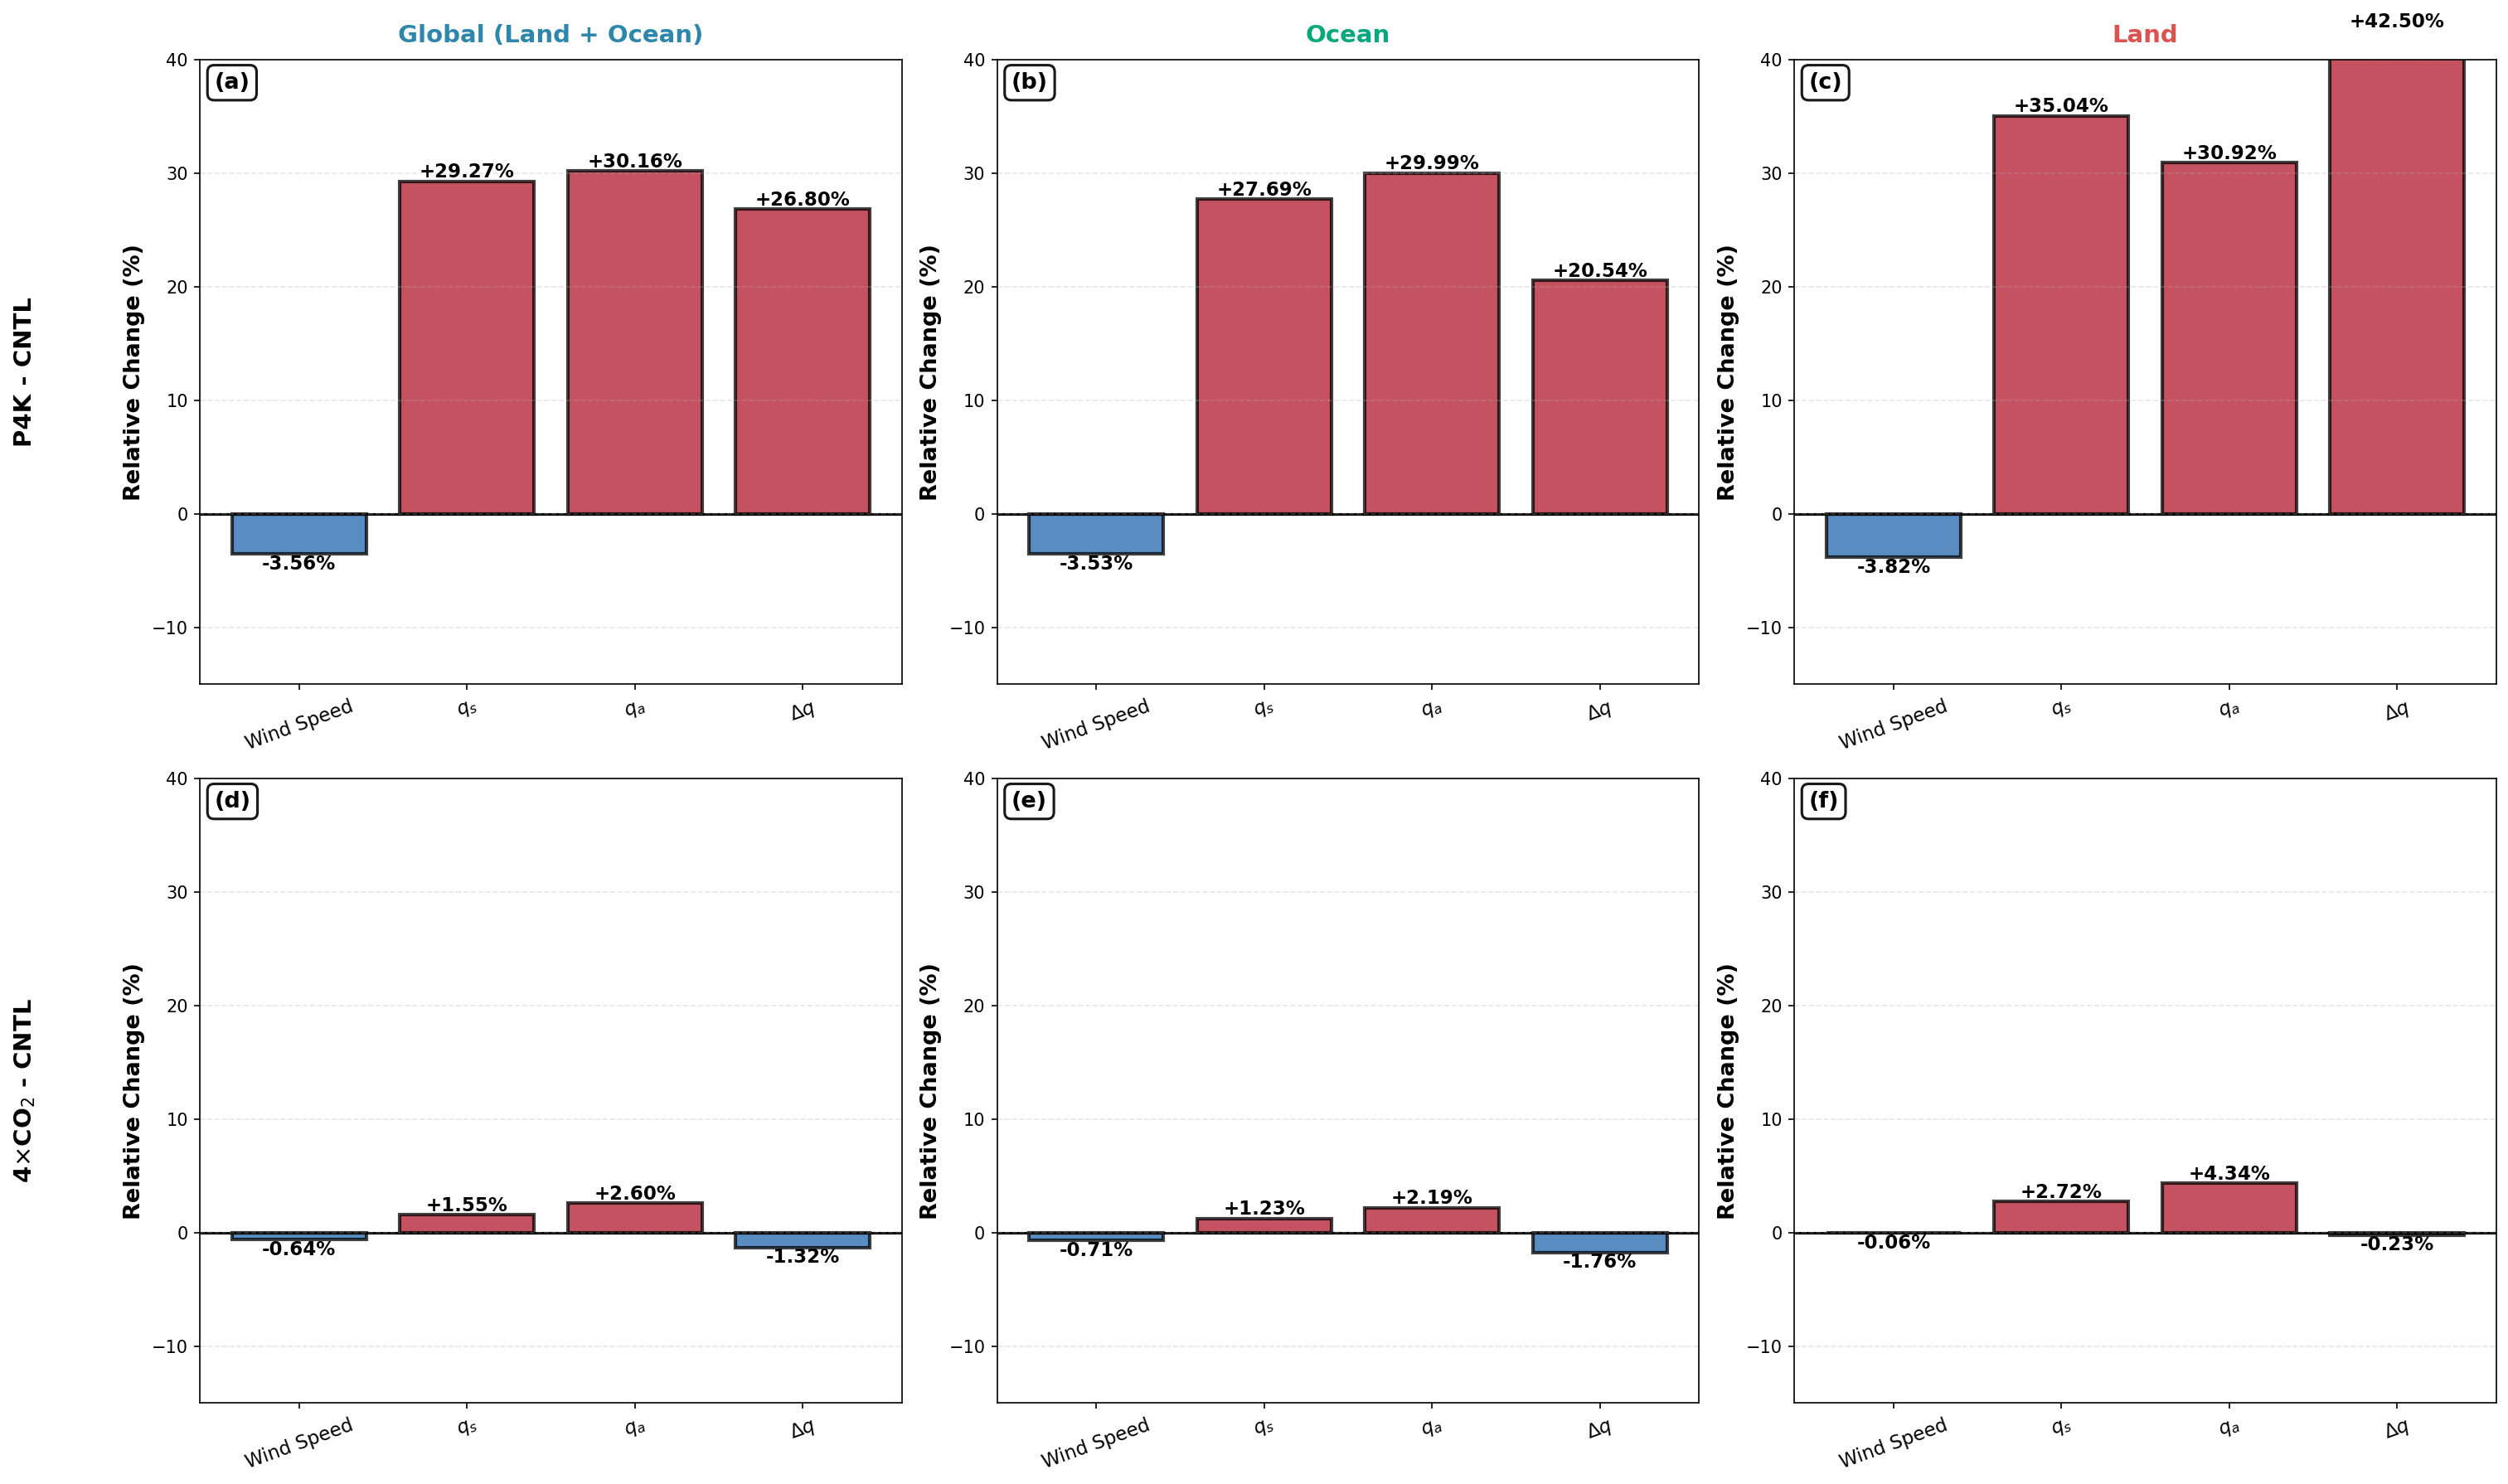

In [74]:
# ============================================================================
# Main Results Figure: Regional Comparison of LHF Factors (including Wind Speed)
# ============================================================================

factors = ['Wind Speed', r'$q_s$', r'$q_a$', r'$\Delta q$']

fig_summary, axes = plt.subplots(2, 3, figsize=(20, 12), dpi=150)

# P4K and 4CO2 experiments
exp_changes = [('p4k', 'P4K'), ('4co2', r'4$\times$CO$_2$')]

for row, (exp_key, exp_label) in enumerate(exp_changes):
    for col, (region_key, region_name) in enumerate(REGIONS.items()):
        ax = axes[row, col]
        
        # Calculate relative changes
        wind_cntl = wind_regional_means[region_key]['cntl']
        wind_exp = wind_regional_means[region_key][exp_key]
        
        qs_cntl = regional_means[region_key]['qs_cntl']
        qs_exp = regional_means[region_key][f'qs_{exp_key}']
        
        qa_cntl = regional_means[region_key]['qa_cntl']
        qa_exp = regional_means[region_key][f'qa_{exp_key}']
        
        dq_cntl = regional_means[region_key]['dq_cntl']
        dq_exp = regional_means[region_key][f'dq_{exp_key}']
        
        changes = [
            (wind_exp - wind_cntl) / wind_cntl * 100,
            (qs_exp - qs_cntl) / qs_cntl * 100,
            (qa_exp - qa_cntl) / qa_cntl * 100,
            (dq_exp - dq_cntl) / dq_cntl * 100
        ]
        
        # Color scheme: blue for negative, red for positive
        colors_bars = ['#2166ac' if x < 0 else '#b2182b' for x in changes]
        
        # Create bar plot
        bars = ax.bar(factors, changes, color=colors_bars, alpha=0.75, 
                      edgecolor='black', linewidth=2)
        
        # Add zero line
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
        
        # Add value labels
        for bar, change in zip(bars, changes):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{change:+.2f}%',
                   ha='center', va='bottom' if height > 0 else 'top',
                   fontsize=11, fontweight='bold')
        
        # Formatting
        ax.set_ylabel('Relative Change (%)', fontsize=13, fontweight='bold')
        ax.set_ylim(-15, 40)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.tick_params(axis='x', rotation=20, labelsize=11)
        
        # Set title
        if row == 0:
            ax.set_title(f'{region_name}', fontsize=14, fontweight='bold', 
                        pad=10, color=colors_regional[region_key])
        
        # Add experiment label on left side
        if col == 0:
            ax.text(-0.25, 0.5, f'{exp_label} - CNTL', transform=ax.transAxes,
                   fontsize=14, fontweight='bold', rotation=90,
                   ha='center', va='center')
        
        # Add panel label
        panel_label = chr(97 + row*3 + col)
        ax.text(0.02, 0.98, f'({panel_label})', transform=ax.transAxes,
               fontsize=13, fontweight='bold', va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                        edgecolor='black', linewidth=1.5))

plt.tight_layout()
plt.savefig(f'{fig_save_dir}/comprehensive_regional_comparison_with_wind.png', dpi=300, bbox_inches='tight')
print("\n✅ Main results figure (with wind speed) saved!")
plt.show()

In [75]:
# ============================================================================
# Statistical Summary with Wind Speed: Regional Comparison
# ============================================================================

print("\n" + "="*100)
print(" "*20 + "Latent Heat Flux Factor Analysis - Regional Comparison Summary (Including Wind)")
print("="*100)

for region_key, region_name in REGIONS.items():
    print(f"\n{'='*100}")
    print(f"🌍 {region_name}")
    print(f"{'='*100}")
    
    for exp_key, exp_label in [('p4k', 'P4K'), ('4co2', '4CO2')]:
        print(f"\n【{exp_label} - CNTL】")
        
        # Wind speed change
        wind_change = (wind_regional_means[region_key][exp_key] - 
                      wind_regional_means[region_key]['cntl']) / \
                      wind_regional_means[region_key]['cntl'] * 100
        
        # Humidity changes
        qs_change = (regional_means[region_key][f'qs_{exp_key}'] - 
                    regional_means[region_key]['qs_cntl']) / \
                    regional_means[region_key]['qs_cntl'] * 100
        
        qa_change = (regional_means[region_key][f'qa_{exp_key}'] - 
                    regional_means[region_key]['qa_cntl']) / \
                    regional_means[region_key]['qa_cntl'] * 100
        
        dq_change = (regional_means[region_key][f'dq_{exp_key}'] - 
                    regional_means[region_key]['dq_cntl']) / \
                    regional_means[region_key]['dq_cntl'] * 100
        
        print(f"  • Wind Speed Change:     {wind_change:+.2f}%")
        print(f"  • qs Change:             {qs_change:+.2f}%")
        print(f"  • qa Change:             {qa_change:+.2f}%")
        print(f"  • dq Change:             {dq_change:+.2f}%")
        
        # Identify dominant factor
        if abs(dq_change) > abs(wind_change):
            dominant = "Humidity Gradient (qs-qa)"
        else:
            dominant = "Wind Speed"
        print(f"  ➜ Dominant Factor: {dominant}")

print("\n" + "="*100)
print("✅ Regional comparison analysis with wind speed completed!")
print("="*100)


                    Latent Heat Flux Factor Analysis - Regional Comparison Summary (Including Wind)

🌍 Global (Land + Ocean)

【P4K - CNTL】
  • Wind Speed Change:     -3.56%
  • qs Change:             +29.27%
  • qa Change:             +30.16%
  • dq Change:             +26.80%
  ➜ Dominant Factor: Humidity Gradient (qs-qa)

【4CO2 - CNTL】
  • Wind Speed Change:     -0.64%
  • qs Change:             +1.55%
  • qa Change:             +2.60%
  • dq Change:             -1.32%
  ➜ Dominant Factor: Humidity Gradient (qs-qa)

🌍 Ocean

【P4K - CNTL】
  • Wind Speed Change:     -3.53%
  • qs Change:             +27.69%
  • qa Change:             +29.99%
  • dq Change:             +20.54%
  ➜ Dominant Factor: Humidity Gradient (qs-qa)

【4CO2 - CNTL】
  • Wind Speed Change:     -0.71%
  • qs Change:             +1.23%
  • qa Change:             +2.19%
  • dq Change:             -1.76%
  ➜ Dominant Factor: Humidity Gradient (qs-qa)

🌍 Land

【P4K - CNTL】
  • Wind Speed Change:     -3.82%
  • qs Change